In [1]:
import os
import osmnx as ox
import city2graph
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D
from shapely.geometry import box
from IPython.display import Markdown, display

%matplotlib inline

D:\GIS\Projects\venvs\copenhagen-walkability\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# helper functions

In [3]:
def plot_net_graph(boundaries_gdf=None, network_gdf=None, nodes_gdf=None, filepath=None, linewidth=0.4, alpha=0.7, color="#2b2b2b", markersize=6):
    fig, ax = plt.subplots()

    if boundaries_gdf is not None:
        boundaries_gdf.boundary.plot(ax=ax, linewidth=0.5, color="#2b2b2b")
    if network_gdf is not None:
        network_gdf.plot(ax=ax, linewidth=linewidth, color=color, alpha=alpha)
    if nodes_gdf is not None:
        nodes_color = "#" + color[6] + color[5] + color[4] + color[3] + color[2] + color[1]
        nodes_gdf.plot(ax=ax, linewidth=linewidth, color=nodes_color, alpha=alpha, markersize=markersize)

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    if type(filename) == str:
        plt.savefig(filepath)

In [4]:
# city and crs
city_name = "Copenhagen Municipality"
crs = 25832

In [5]:
# administrative boundaries
admin_boundaries = ox.geocode_to_gdf(city_name).to_crs(crs)

In [6]:
# administrative boundaries with districts
filename = "municipality-copenhagen-10-districts.json"
districts_filepath = os.path.join("..", "data", filename)
admin_boundaries_districts = gpd.read_file(filename=districts_filepath).to_crs(crs)

In [7]:
# café locations
cafes = ox.features_from_place(city_name, {"amenity": "cafe"}).to_crs(crs)
cafes["geometry"] = cafes.geometry.centroid

In [8]:
# roads accessible to pedestrians
network_walk = ox.graph_to_gdfs(ox.graph_from_place(city_name, network_type="walk"), nodes=False).to_crs(crs)

In [9]:
# maps and tables

In [10]:
# colors
c_cafe = "#8c510a"
c_network_walk = "#5ab4ac"
c_boundary = "#2b2b2b"

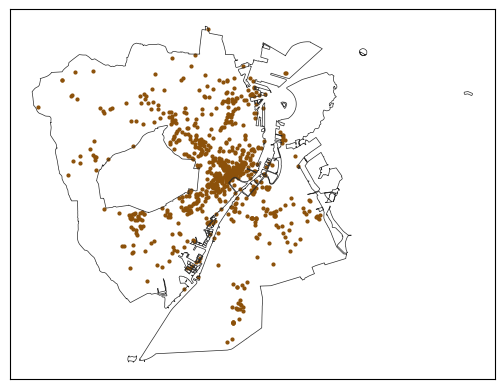

In [11]:
fig, ax = plt.subplots()  

admin_boundaries.boundary.plot(ax=ax, linewidth=0.5, color=c_boundary)
cafes.plot(ax=ax, markersize=4, color=c_cafe)

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

plt.savefig(r"../docs/cafes_locations.png")

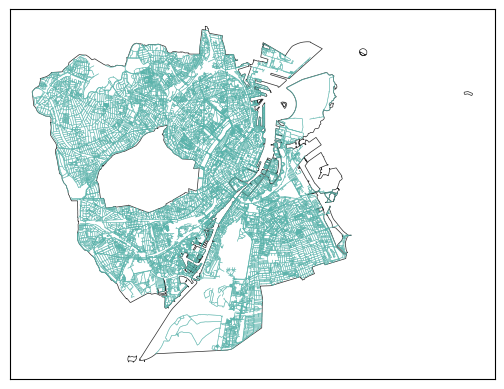

In [12]:
plot_net_graph(admin_boundaries, network_walk, color=c_network_walk, filepath=r"../docs/walkable_paths.png")

In [13]:
# ax = districts.boundary.plot(
#     figsize=(8,8),
#     linewidth=0.5,
#     color="#2b2b2b"
# )

# for _, row in districts.iterrows():
#     point = row.geometry.representative_point()
#     ax.annotate(
#         text=row["navn"],
#         xy=(point.x, point.y),
#         ha="center",
#         fontsize=9
#     )
# plt.show()

In [14]:
# number of cafés in the districts
joined = gpd.sjoin(
    cafes,
    admin_boundaries_districts,
    how="left",
    predicate="within"
)
cafe_counts = joined.groupby("navn").size().rename("cafe_count")
admin_boundaries_districts = admin_boundaries_districts.merge(
    cafe_counts,
    on="navn",
    how="left",
    suffixes=(None, "_y")
)
admin_boundaries_districts["cafe_count"] = admin_boundaries_districts["cafe_count"].fillna(0)
admin_boundaries_districts["area_km2"] = (admin_boundaries_districts.area / 1_000_000).round(1)
admin_boundaries_districts["cafes_per_km2"] = (admin_boundaries_districts["cafe_count"] / admin_boundaries_districts["area_km2"]).round(1)
admin_boundaries_districts.sort_values(by="cafes_per_km2", ascending=False, inplace=True)

In [15]:
display(
    Markdown(
        admin_boundaries_districts[["navn", "cafe_count", "area_km2", "cafes_per_km2"]].sort_values(
            by="cafes_per_km2",
            ascending=False).rename(
            columns={
                "navn": "Nazwa dzielnicy",
                "cafe_count": "Liczba kawiarni",
                "area_km2": "Powierzchnia dzielnicy [km2]",
                "cafes_per_km2": "Ilość kawiarni na km2"
            }).to_markdown(
            index=False
        )
    )
)

| Nazwa dzielnicy           |   Liczba kawiarni |   Powierzchnia dzielnicy [km2] |   Ilość kawiarni na km2 |
|:--------------------------|------------------:|-------------------------------:|------------------------:|
| Indre By                  |               304 |                           10.5 |                    29   |
| Nørrebro                  |                86 |                            4.1 |                    21   |
| Vesterbro-Kongens Enghave |               102 |                            8.3 |                    12.3 |
| Østerbro                  |                82 |                            9.8 |                     8.4 |
| Valby                     |                39 |                            9.2 |                     4.2 |
| Amager Vest               |                69 |                           19.4 |                     3.6 |
| Amager Øst                |                33 |                            9.3 |                     3.5 |
| Bispebjerg                |                21 |                            6.8 |                     3.1 |
| Vanløse                   |                17 |                            6.7 |                     2.5 |
| Brønshøj-Husum            |                14 |                            8.7 |                     1.6 |

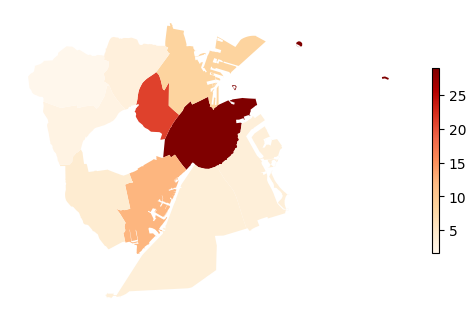

In [16]:
ax = admin_boundaries_districts.plot(
    column="cafes_per_km2",
    legend=True,
    cmap="OrRd",
    legend_kwds={
        "shrink": 0.5,
        "aspect": 25
    }
)
ax.set_axis_off()
plt.savefig(r"..\docs\number_cafes.png")

In [17]:
# café service areas

In [18]:
# map with 10-minute isochrones (map)
# Which parts of the city are within a 10-minute walk of a café?
# 10 min (800 m)
cafe_isochrones_10min = city2graph.create_isochrone(
    edges=network_walk,
    center_point=cafes,
    threshold=800,
    edge_attr="length",
    method="buffer"
)
cafe_isochrones_10min_clipped = gpd.clip(cafe_isochrones_10min, admin_boundaries)

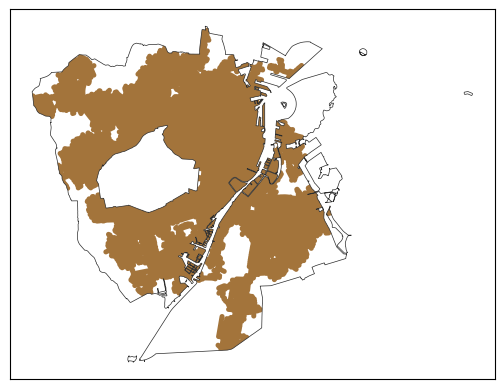

In [19]:
plot_net_graph(admin_boundaries, cafe_isochrones_10min_clipped, filepath=r"..\docs\cafes_10min_isochrones.jpg", color=c_cafe, alpha=0.8)

In [20]:
# pct of the municipality area covered by 10-minutes cafés isochrones
cafe_isochrones_10min_clipped.geometry.area / admin_boundaries.geometry.area

0    0.686835
dtype: float64